# File to DO EDA on the Intensities dataset 

### Constants

In [1]:
from enum import Enum
import gc
from pathlib import Path

curr_dir_parent = Path.cwd().parent
DATASET_PATH = curr_dir_parent / "data/processed/intensities_t1.csv"


class T1ModelSchema(str, Enum):
	"""Enumeration of active features and target used in Tier 1 model training.

	Predictors (X):
		MAG: Preferred earthquake magnitude (Mw).
		MMI: Observed Modified Mercalli Intensity shaking threshold.
		DEPTH_S: Focal depth relative to DEM ground surface (km).
		REGIME: Tectonic regime classification (e.g., subduction, crustal).

	Target (y):
		RHYPO: 3D straight-line hypocentral distance (km).
	"""

	MAG = "magnitude"
	MMI = "mmi"
	DEPTH_S = "depth_surface"
	REGIME = "regime"
	RHYPO = "r_hypo"

ALL_FEATURES = [T1ModelSchema.MAG.value, T1ModelSchema.MMI.value, T1ModelSchema.DEPTH_S.value, T1ModelSchema.REGIME.value]
ALL_PROPERTIES =ALL_FEATURES + [T1ModelSchema.RHYPO.value]
NUMERIC_PROPERTIES = [T1ModelSchema.MAG.value, T1ModelSchema.MMI.value, T1ModelSchema.DEPTH_S.value, T1ModelSchema.RHYPO.value]

NUMERIC_PROPERTIES_FOR_MODEL = [T1ModelSchema.MAG.value, T1ModelSchema.MMI.value, T1ModelSchema.RHYPO.value]

class MetadataSchema(str, Enum):
	"""Enumeration of passive metadata and auxiliary spatial features.

	Used for GroupKFold splitting keys, spatial indexing, and coordinate references.
	These are excluded from the direct model input vector.
	"""
	ID = "usgs_id"
	LONGITUDE = "longitude"
	LATITUDE = "latitude"
	DEPTH_F = "depth_from_sea"
	ELEVATION = "elevation"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(DATASET_PATH)

# Basic Information about the dataset
- shape of the dataset
- information about the dataset
- describe the dataset
- duplicated rows in the dataset
- check for null values in the dataset

In [3]:
df.shape

(672040, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 672040 entries, 0 to 672039
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   usgs_id         672040 non-null  str    
 1   longitude       672040 non-null  float64
 2   latitude        672040 non-null  float64
 3   magnitude       672040 non-null  float64
 4   mmi             672040 non-null  float64
 5   depth_from_sea  672040 non-null  float64
 6   regime          672040 non-null  str    
 7   r_hypo          672040 non-null  float64
 8   elevation       672040 non-null  float64
 9   depth_surface   672040 non-null  float64
dtypes: float64(8), str(2)
memory usage: 51.3 MB


In [5]:
df.describe()

,longitude,latitude,magnitude,mmi,depth_from_sea,r_hypo,elevation,depth_surface
count,672040.000000,672040.000000,672040.000000,672040.000000,672040.000000,672040.000000,672040.000000,672040.000000
mean,-118.650033,36.704509,4.416974,2.871118,10.772887,88.564560,0.637484,11.412593
std,2.895354,3.778643,1.045155,0.954404,6.620741,97.138831,0.641012,6.495197
min,-126.193600,30.793600,3.000000,1.000000,-3.340000,0.562028,-0.079000,0.000000
25%,-121.610500,33.948500,3.600000,2.200000,7.302000,26.250335,0.087000,8.006000
50%,-118.163300,35.705330,4.190000,2.700000,9.990000,53.610165,0.455000,10.541000
75%,-116.914700,38.168900,4.990000,3.400000,13.051000,117.410800,0.967000,14.038000
max,-105.182000,49.203300,7.300000,9.100000,76.200000,1834.186000,3.428000,78.905000


In [6]:
df.head()

,usgs_id,longitude,latitude,magnitude,mmi,depth_from_sea,regime,r_hypo,elevation,depth_surface
0,nc71729135,-122.7432,38.79267,4.16,5.8,0.477,active,2.129752,1.045,1.522
1,nc72737985,-122.8413,38.82217,5.01,5.8,1.480,active,2.670254,0.606,2.086
2,ci3031111,-116.4370,34.20000,7.30,7.9,-0.097,active,10.555350,1.054,0.957
3,nn00385392,-119.9393,39.52310,5.10,6.7,2.800,subduction,3.029873,1.461,4.261
4,nc72737985,-122.8413,38.82217,5.01,6.1,1.480,active,2.307831,0.606,2.086


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum()

usgs_id           0
longitude         0
latitude          0
magnitude         0
mmi               0
depth_from_sea    0
regime            0
r_hypo            0
elevation         0
depth_surface     0
dtype: int64

## checking if the MMI values are less than 3,
- since they are also important for the analysis, I will not drop them, but I will keep a note of how many such values are there

In [9]:

print(len(df[df[T1ModelSchema.MMI] < 3]))

376856


In [10]:
def calculate_plot_dimension(count:int)-> tuple[int, int]:
	horizontal = int(np.ceil(np.sqrt(count)))
	vertical = int(np.ceil(count / horizontal))
	if horizontal * vertical < count:
		vertical += 1
	if horizontal < vertical:
		horizontal, vertical = vertical, horizontal
	return (horizontal, vertical)


### Histogram of All Predictors and Target

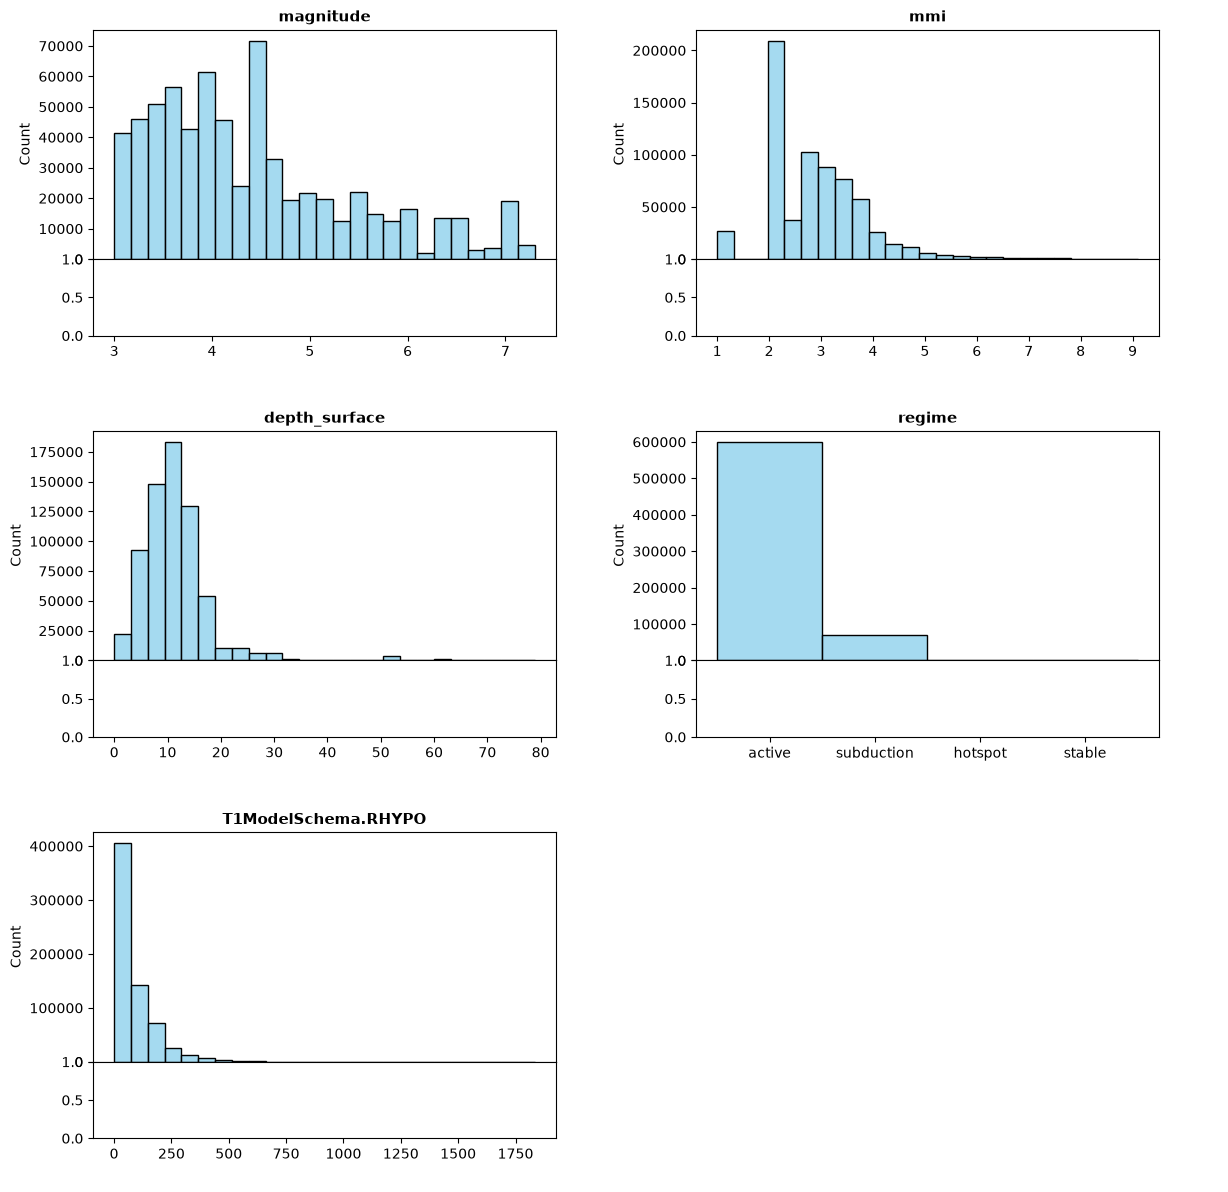

254

In [11]:
import gc


fig = plt.figure(figsize=(12, 12))

h,v = calculate_plot_dimension(len(ALL_PROPERTIES))

subfigs = fig.subfigures(h, v, wspace=0.01, hspace=0.01).flatten()

for i, col in enumerate(ALL_FEATURES+[T1ModelSchema.RHYPO]):
	ax1, ax2 = subfigs[i].subplots(
		2, 1, 
		sharex=True, 
		gridspec_kw={"height_ratios": [3, 1]}
	)
	sns.histplot(
		data=df, 
		x=col, 
		bins=25, 
		color="skyblue",                         
		ax=ax1
	)
	ax1.set_title(f"{col}", fontsize=11, fontweight="bold")
	ax1.set_xlabel("")
	subfigs[i].subplots_adjust(hspace=0)

plt.show()

del fig, subfigs, ax1, ax2, h, v, i, col
gc.collect()

### Box plot for all predictors and target variable

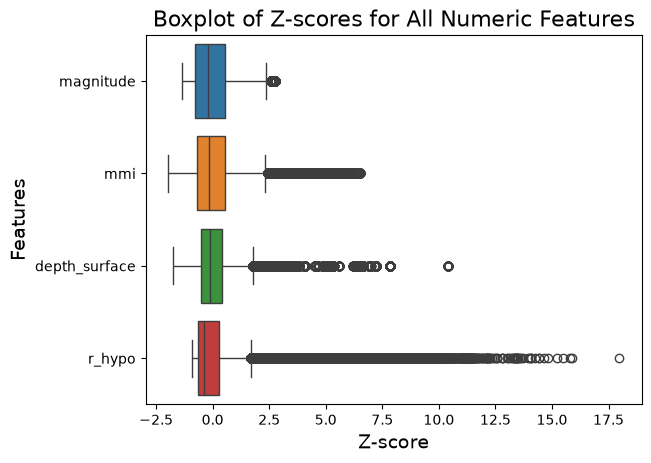

28358

In [12]:
numeric_df = df[ALL_PROPERTIES].select_dtypes(include="number")
z = (numeric_df - numeric_df.mean()) / numeric_df.std()
sns.boxplot(
	data=z,
	orient="h",
)
plt.title("Boxplot of Z-scores for All Numeric Features", fontsize=16)
plt.xlabel("Z-score", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.show()

del numeric_df, z
gc.collect()

### Combined Figures for Histograms and Boxplots

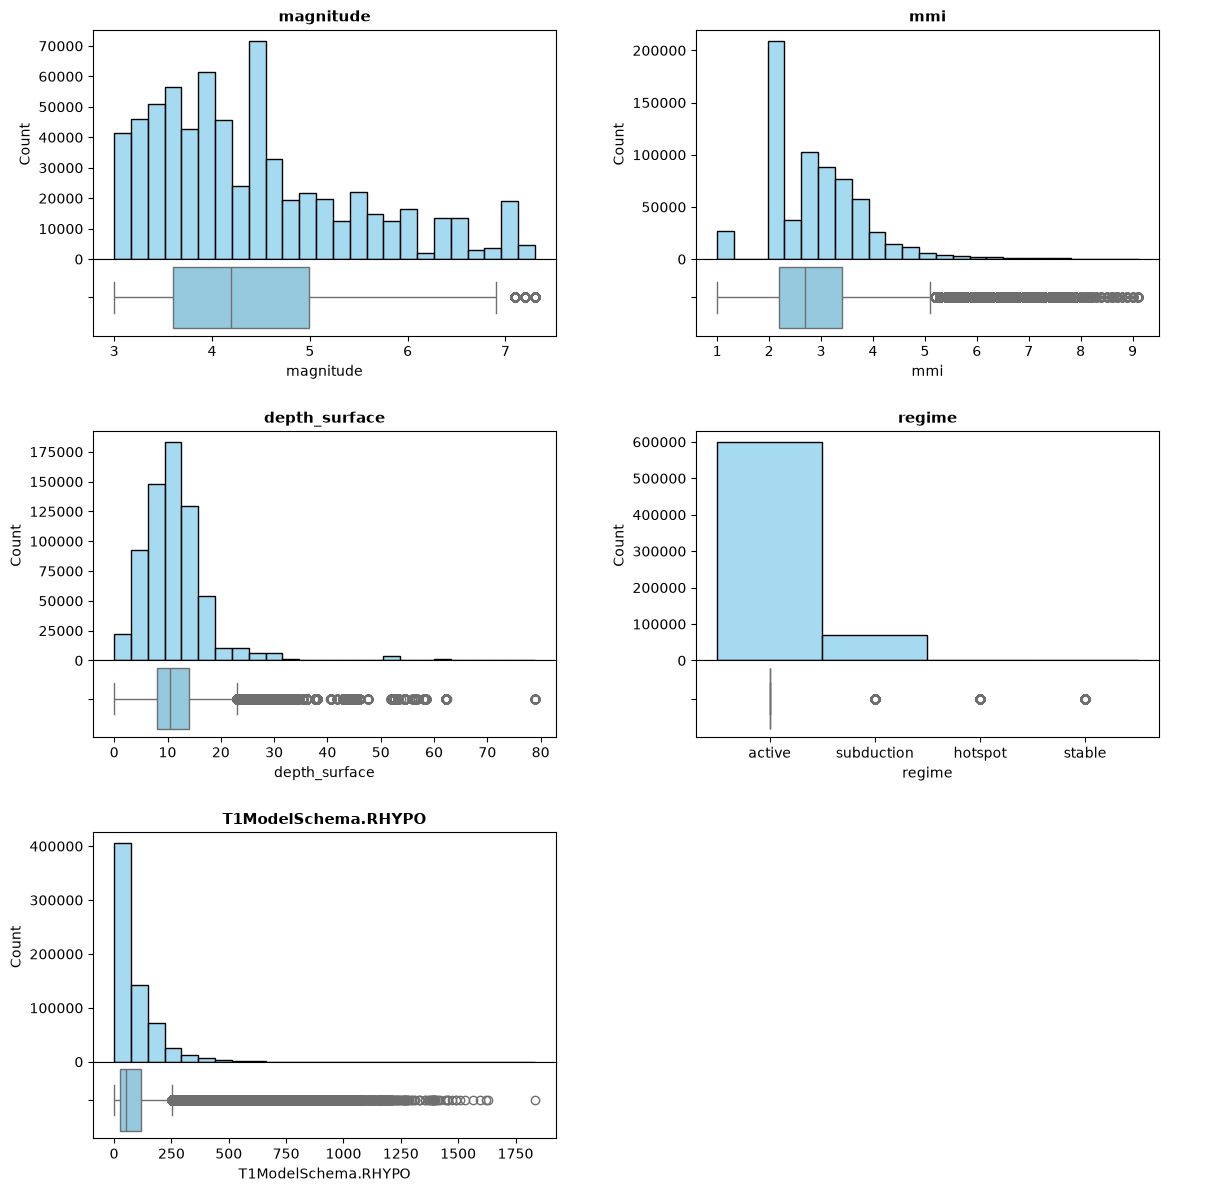

4302

In [13]:
import gc


fig = plt.figure(figsize=(12, 12))

h,v = calculate_plot_dimension(len(ALL_PROPERTIES))

subfigs = fig.subfigures(h, v, wspace=0.01, hspace=0.01).flatten()

for i, col in enumerate(ALL_FEATURES+[T1ModelSchema.RHYPO]):
	ax1, ax2 = subfigs[i].subplots(
		2, 1, 
		sharex=True, 
		gridspec_kw={"height_ratios": [3, 1]}
	)
	
	sns.histplot(
		data=df, 
		x=col, 
		bins=25, 
		color="skyblue",                         
		ax=ax1
	)
	
	ax1.set_title(f"{col}", fontsize=11, fontweight="bold")
	ax1.set_xlabel("")
	
	sns.boxplot(data=df, x=col, color="skyblue", ax=ax2)
	subfigs[i].subplots_adjust(hspace=0)

plt.show()

del fig, subfigs, ax1, ax2, h, v, i, col
gc.collect()

### HeatMap of Correlation Matrix


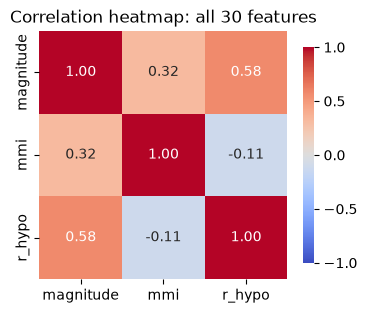

33439

In [14]:
plt.figure(figsize=(4, 4))
numeric_df = df[NUMERIC_PROPERTIES_FOR_MODEL]
numeric_labels = numeric_df.columns.tolist()

correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, xticklabels=numeric_labels, yticklabels=numeric_labels, 
			cmap="coolwarm", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
			square=True, cbar_kws={"shrink": 0.7})
plt.title("Correlation heatmap: all 30 features")
plt.show()

del numeric_df, correlation_matrix
gc.collect()

In [15]:
def add_grid_sample_flag(
    df,
    x_col,
    y_col,
    x_bins=15,
    y_bins=15,
    max_per_bin=50,
    flag_col="is_sampled",
    random_state=42,
):
  """Annotates the full DataFrame with a boolean column indicating which rows belong to the 2D grid sample."""
  df_result = df.copy()

  x_bin = pd.cut(df_result[x_col], bins=x_bins)
  y_bin = pd.cut(df_result[y_col], bins=y_bins)

  sampled_indices = (
      df_result.groupby([x_bin, y_bin], observed=False, group_keys=False)
      .apply(
          lambda group: group.sample(
              n=min(len(group), max_per_bin), random_state=random_state
          )
      )
      .index
  )
  df_result[flag_col] = df_result.index.isin(sampled_indices)

  return df_result


### Pair Plot of All Numeric Properties

This will take a while to run, please be patient...


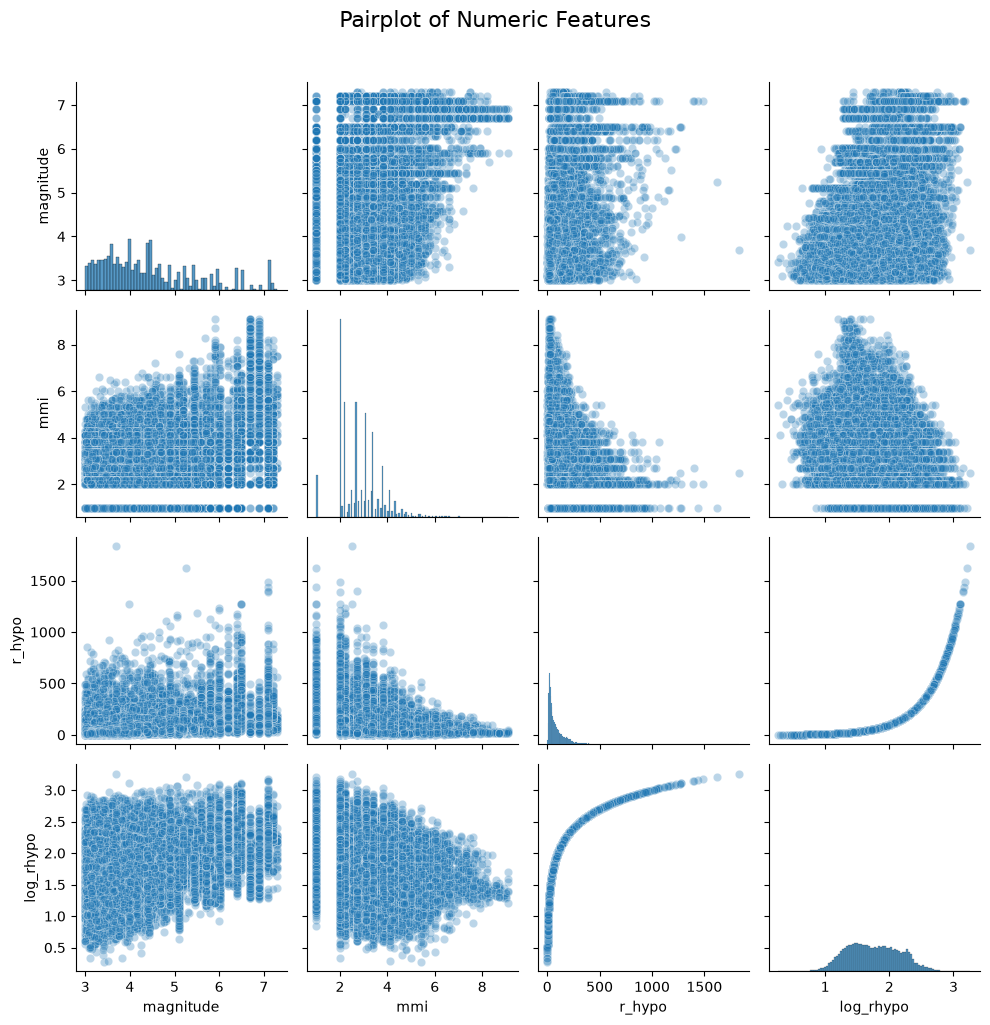

596

In [16]:
print("This will take a while to run, please be patient...")
sub_df = df.sample(frac=0.1, random_state=42)
sub_df["log_rhypo"] = np.log10(sub_df[T1ModelSchema.RHYPO.value] + 1)

sns.pairplot(
	data=sub_df,
	vars=NUMERIC_PROPERTIES_FOR_MODEL+["log_rhypo"],
	plot_kws={'alpha': 0.3}
)
plt.suptitle("Pairplot of Numeric Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

del sub_df
gc.collect()

### Scatter Plot With Targer

#### 1 / rhypo scatter plot

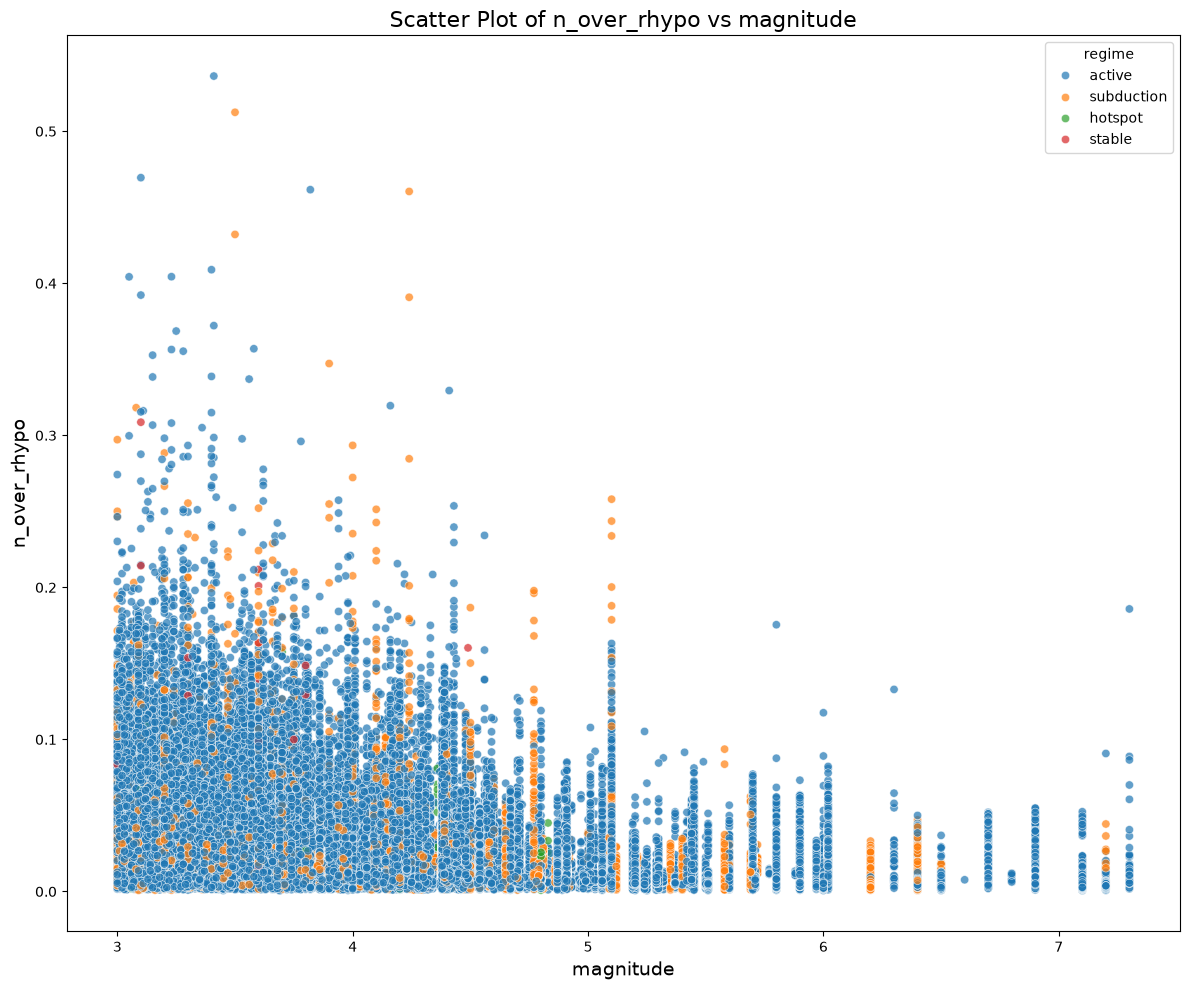

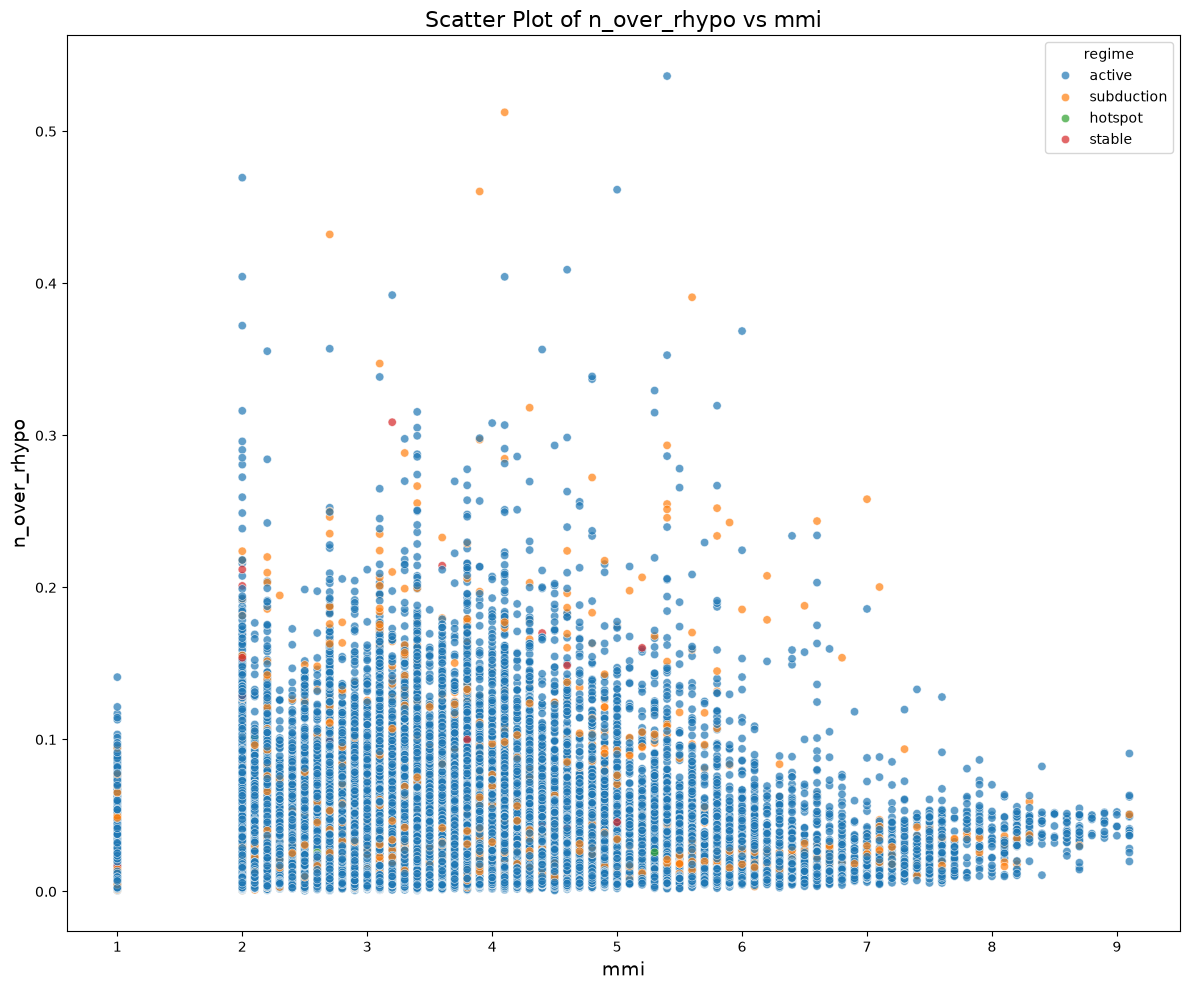

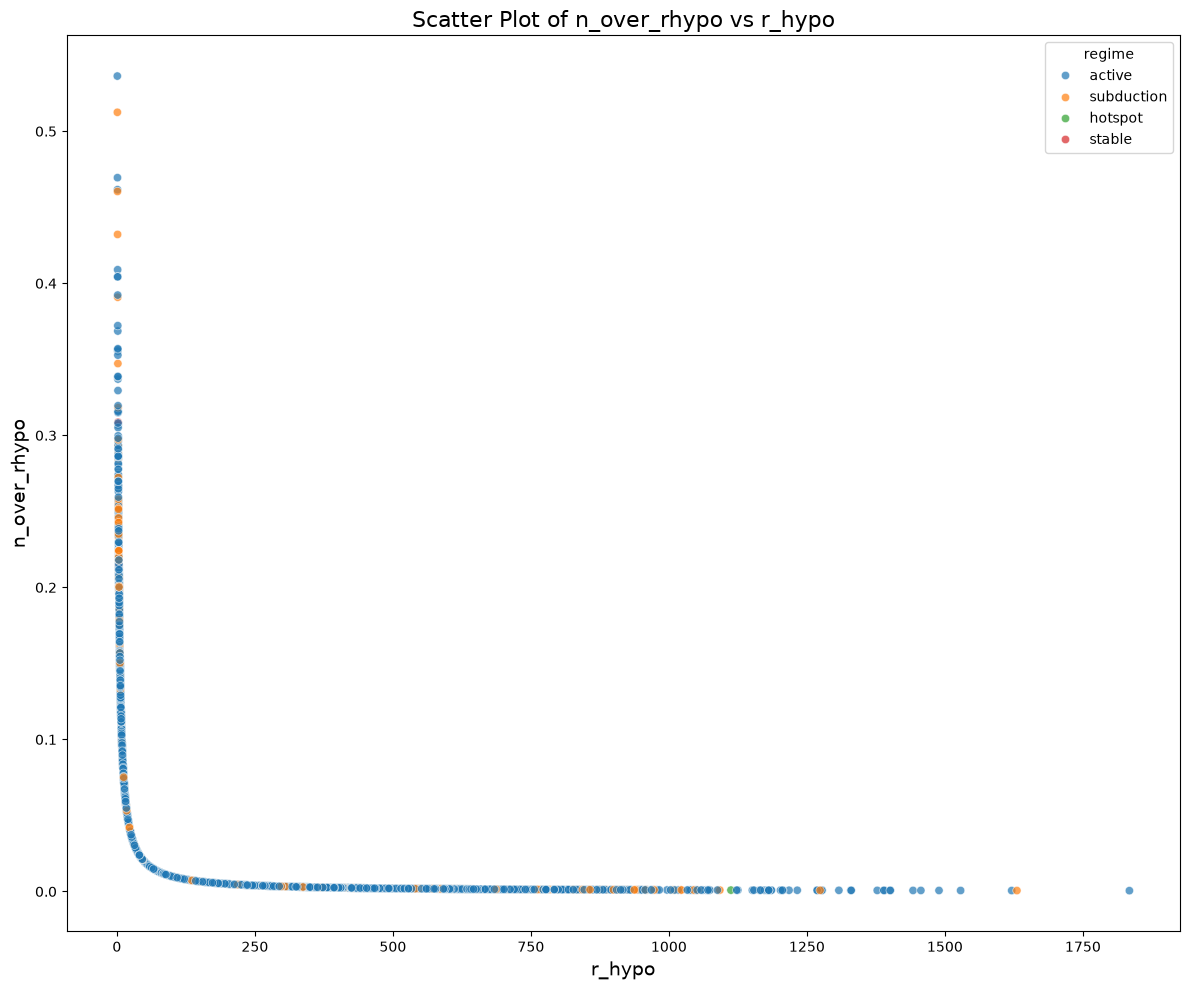

84144

In [17]:
target_feature = "n_over_rhypo"
used_feature = [
    T1ModelSchema.MAG.value,
    T1ModelSchema.MMI.value,
    T1ModelSchema.RHYPO.value,
]

graph_df = df.sample(frac=0.25, random_state=42).copy()
graph_df[target_feature] = 1 / (graph_df[T1ModelSchema.RHYPO.value] + 1)

for col in used_feature:
  plt.figure(figsize=(12, 10))
  sns.scatterplot(
      data=graph_df,
      x=col,
      y=target_feature,
      hue=T1ModelSchema.REGIME.value,
      alpha=0.7,
  )
  plt.title(f"Scatter Plot of {target_feature} vs {col}", fontsize=16)
  plt.xlabel(col, fontsize=14)
  plt.ylabel(target_feature, fontsize=14)  # Updated y-label to match target
  plt.legend(title=T1ModelSchema.REGIME.value)
  plt.tight_layout()
  plt.show()

del graph_df, used_feature, target_feature
gc.collect()

#### log_rhypo scatter plot

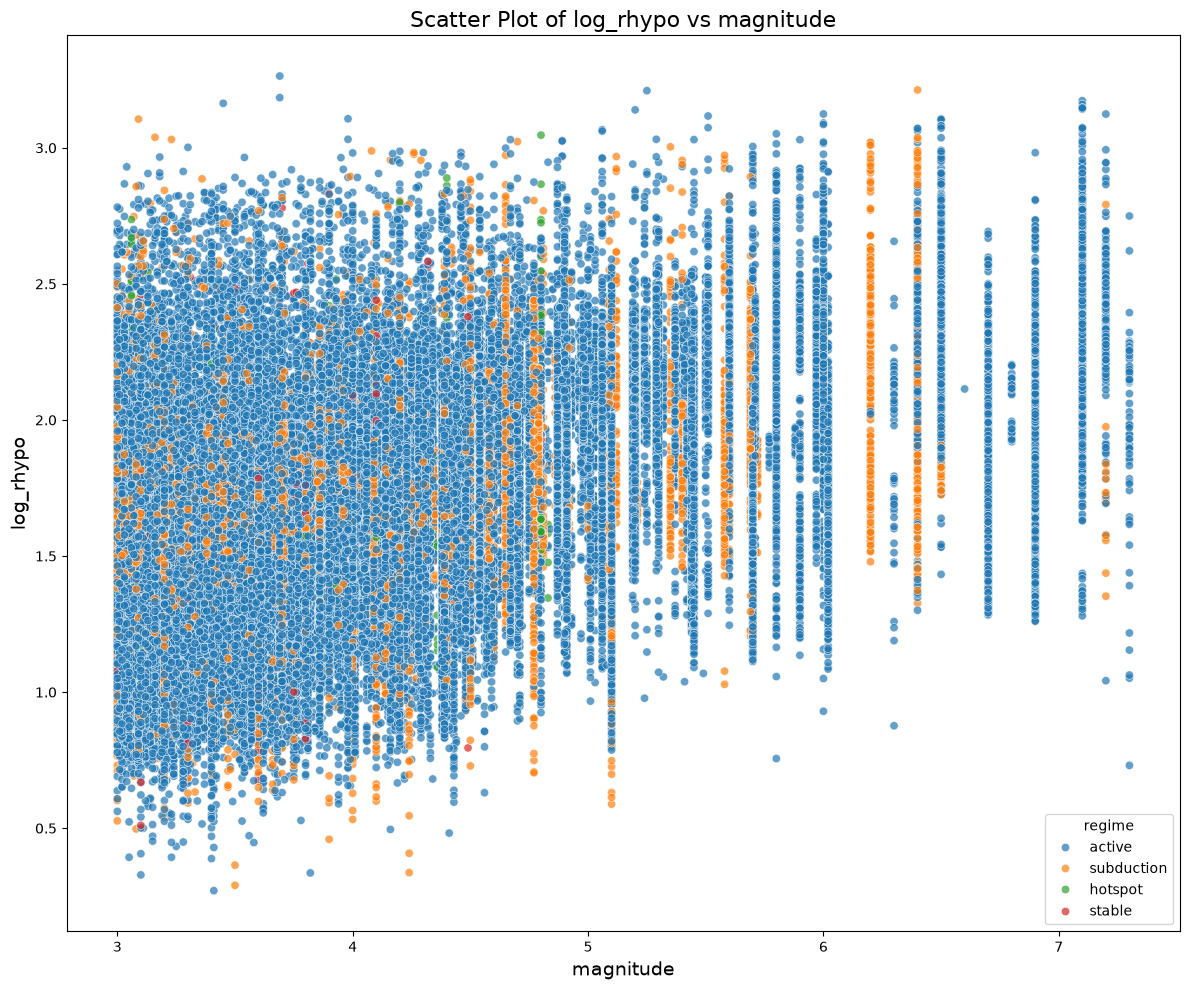

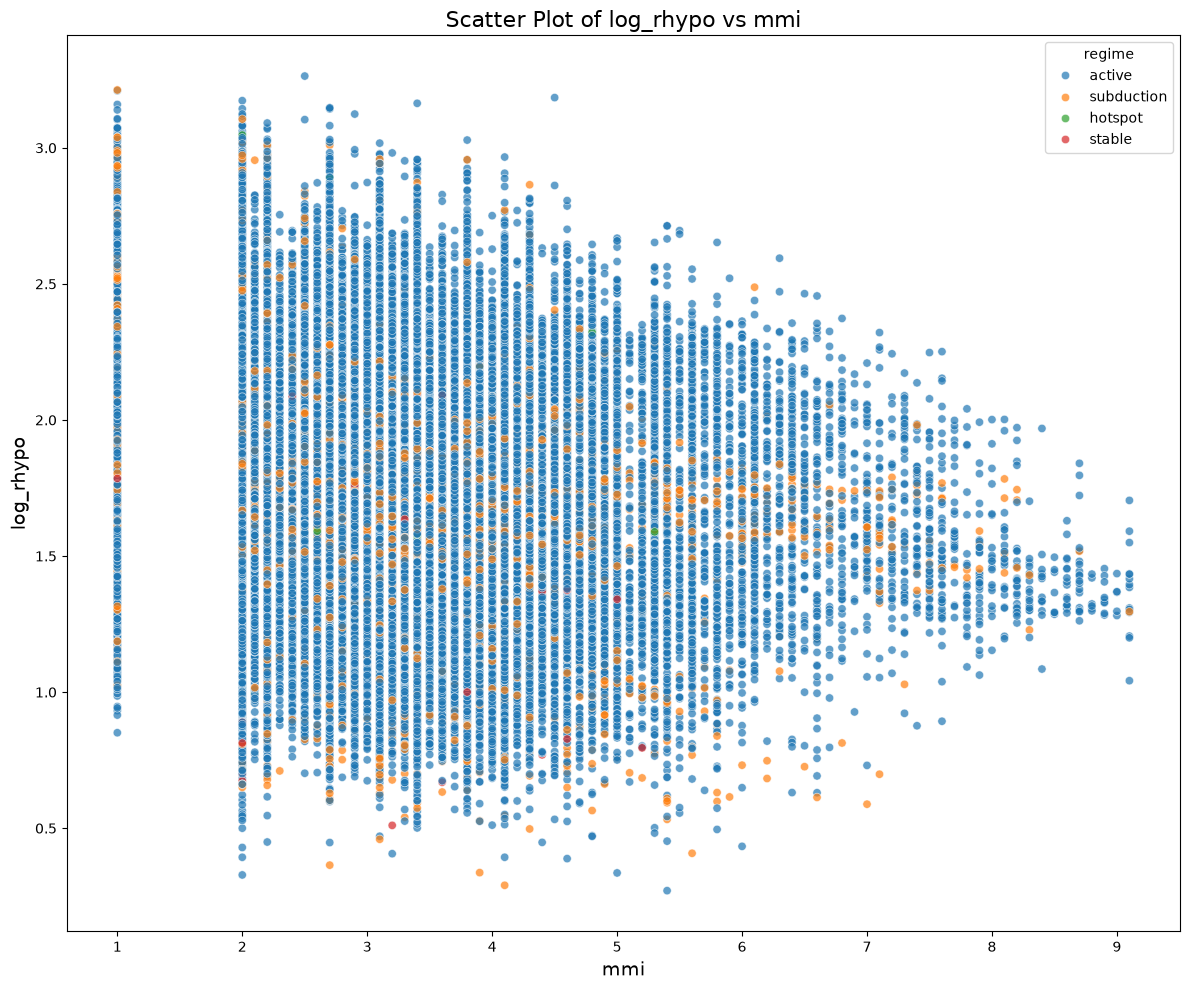

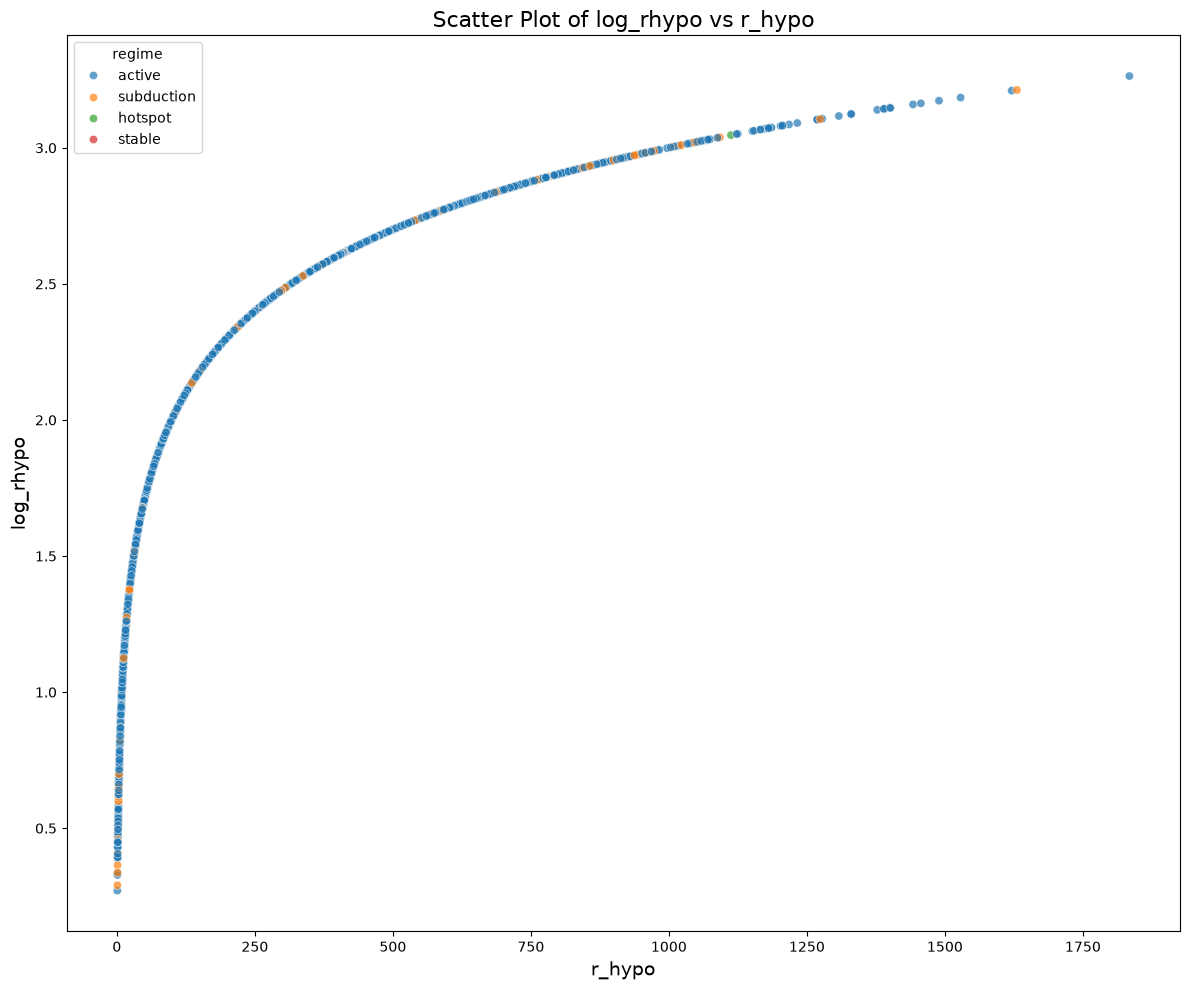

11298

In [18]:
target_feature = "log_rhypo"
used_feature = [
    T1ModelSchema.MAG.value,
    T1ModelSchema.MMI.value,
    T1ModelSchema.RHYPO.value,
]

graph_df = df.sample(frac=0.25, random_state=42).copy()
graph_df[target_feature] = np.log10(graph_df[T1ModelSchema.RHYPO.value]+1) 

for col in used_feature:
  plt.figure(figsize=(12, 10))
  sns.scatterplot(
      data=graph_df,
      x=col,
      y=target_feature,
      hue=T1ModelSchema.REGIME.value,
      alpha=0.7,
  )
  plt.title(f"Scatter Plot of {target_feature} vs {col}", fontsize=16)
  plt.xlabel(col, fontsize=14)
  plt.ylabel(target_feature, fontsize=14)  # Updated y-label to match target
  plt.legend(title=T1ModelSchema.REGIME.value)
  plt.tight_layout()
  plt.show()

del graph_df, used_feature, target_feature
gc.collect()

####  1/m vs log(rhypo) scatter plot

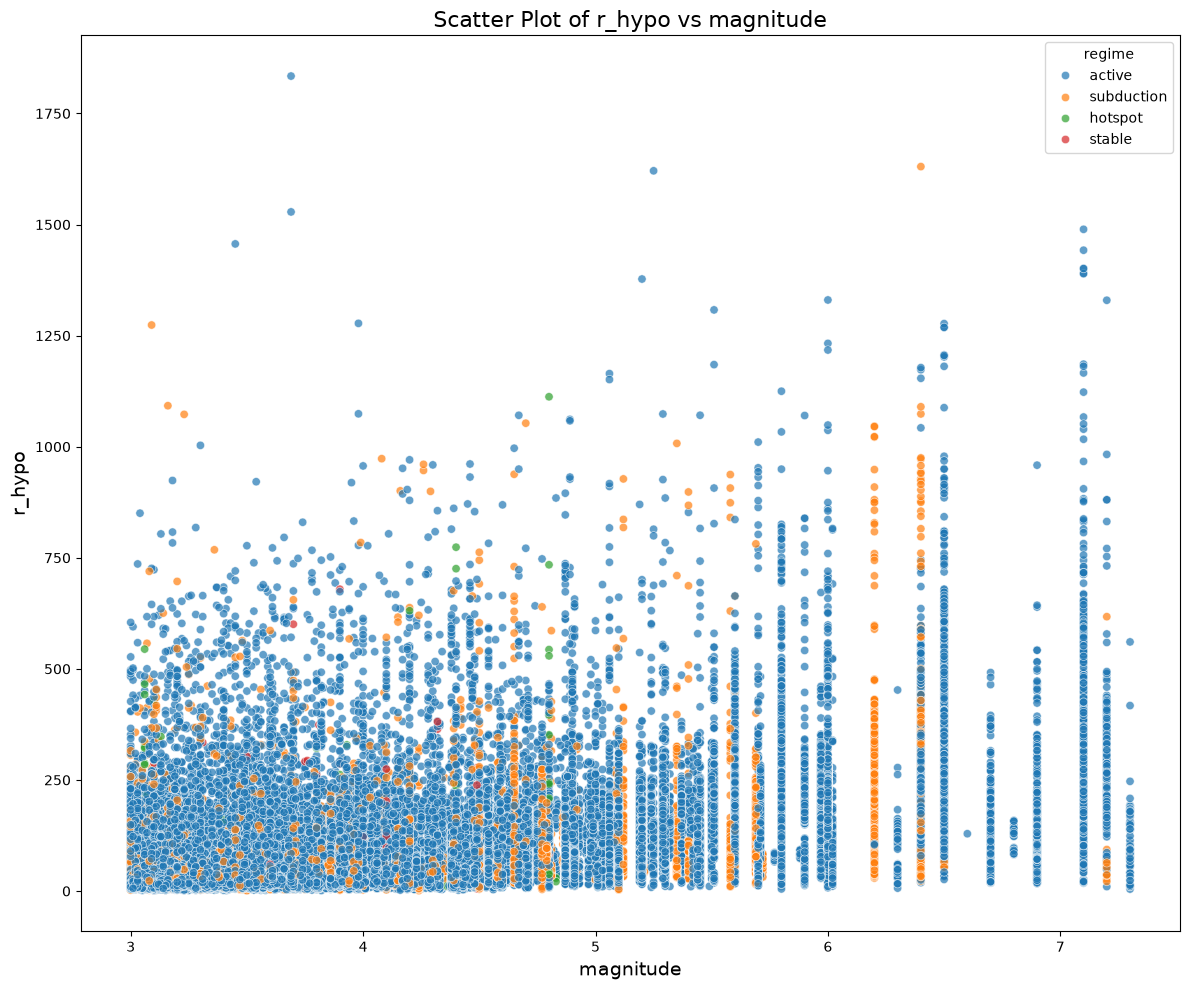

7716

In [19]:

X = "magnitude"
Y = T1ModelSchema.RHYPO.value

graph_df = df.sample(frac=0.25, random_state=42).copy()



plt.figure(figsize=(12, 10))
sns.scatterplot(
	data=graph_df,
	x=X,
	y=Y,
	hue=T1ModelSchema.REGIME.value,
	alpha=0.7,
)
plt.title(f"Scatter Plot of {Y} vs {X}", fontsize=16)
plt.xlabel(X, fontsize=14)
plt.ylabel(Y, fontsize=14)  # Updated y-label to match target
plt.legend(title=T1ModelSchema.REGIME.value)
plt.tight_layout()
plt.show()


del graph_df, X, Y
gc.collect()

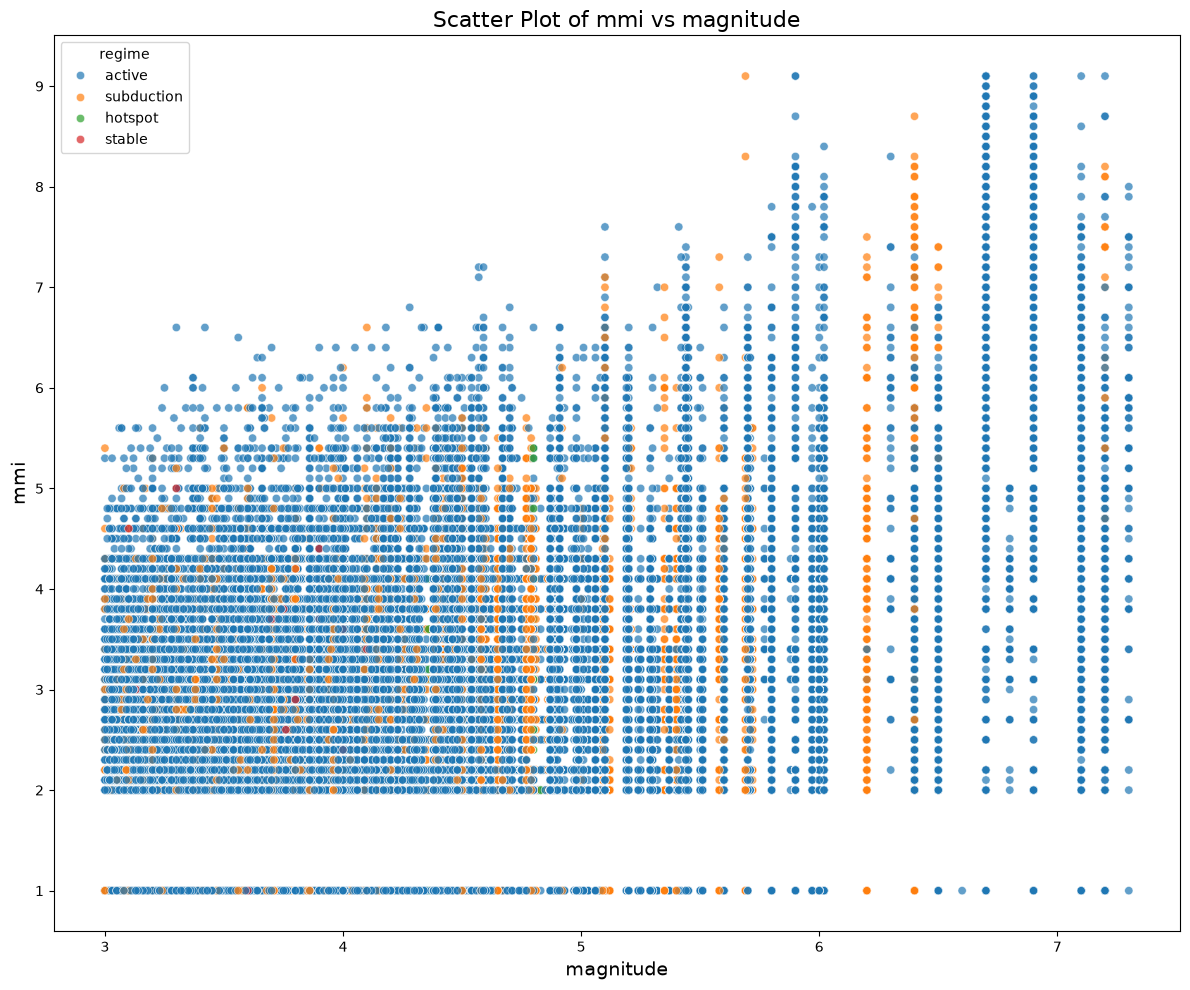

4074

In [20]:

X = T1ModelSchema.MAG.value
Y = T1ModelSchema.MMI.value

graph_df = df.sample(frac=0.25, random_state=42).copy()

plt.figure(figsize=(12, 10))
sns.scatterplot(
	data=graph_df,
	x=X,
	y=Y,
	hue=T1ModelSchema.REGIME.value,
	alpha=0.7,
)
plt.title(f"Scatter Plot of {Y} vs {X}", fontsize=16)
plt.xlabel(X, fontsize=14)
plt.ylabel(Y, fontsize=14)
plt.legend(title=T1ModelSchema.REGIME.value)
plt.tight_layout()
plt.show()


del graph_df, X, Y
gc.collect()

### Unique Value Plots

In [21]:
from typing import List, Union
import pandas as pd


def filter_by_unique_extrema(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    operations: Union[str, List[str]] = ["highest", "lowest"],
) -> pd.DataFrame:
  """Filters the DataFrame to keep full rows where `y_col` hits the specified extreme value(s) for each unique `x_col`.

  Args:
      df: Input Pandas DataFrame.
      x_col: Column to group by for unique values.
      y_col: Target column to find extreme values (e.g. min/max).
      operations: String or list of strings ('highest'/'max', 'lowest'/'min').

  Returns:
      pd.DataFrame containing all original columns, filtered down to only the
      extreme rows.
  """
  if isinstance(operations, str):
    operations = [operations]

  target_indices = set()

  for op in operations:
    op_clean = op.lower().strip()

    if op_clean in ["highest", "max"]:
      # Index of the row with the maximum y_col per x_col group
      idx = df.groupby(x_col)[y_col].idxmax().dropna()
      target_indices.update(idx)

    elif op_clean in ["lowest", "min"]:
      # Index of the row with the minimum y_col per x_col group
      idx = df.groupby(x_col)[y_col].idxmin().dropna()
      target_indices.update(idx)

    else:
      raise ValueError(
          f"Unsupported operation '{op}'. Supported: ['highest', 'max',"
          " 'lowest', 'min']"
      )

  # Filter original dataframe using the collected index positions
  filtered_df = (
      df.loc[sorted(list(target_indices))].copy().reset_index(drop=True)
  )

  return filtered_df

#### Filteration by unique hypocentral distance and maximum magnitude

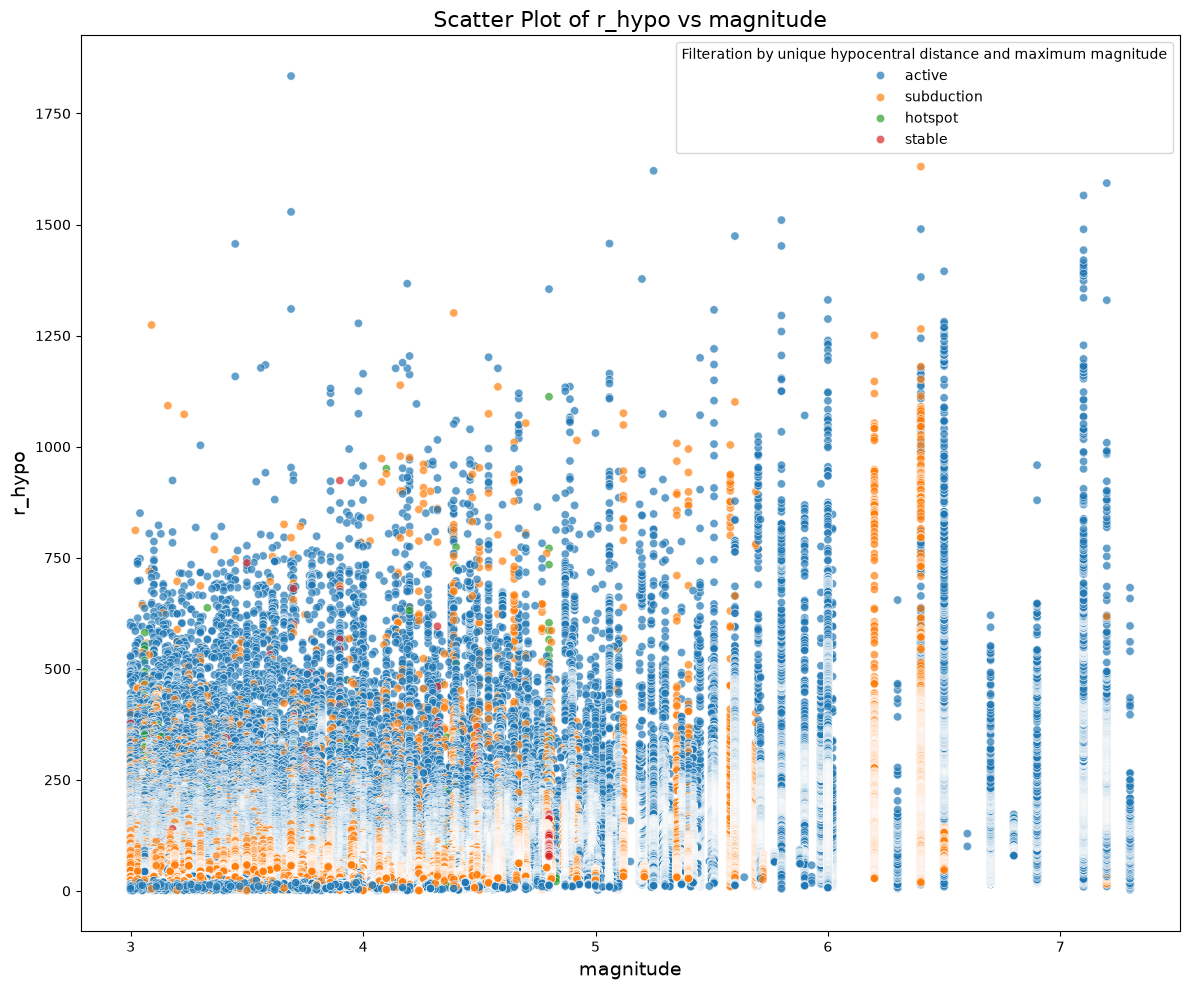

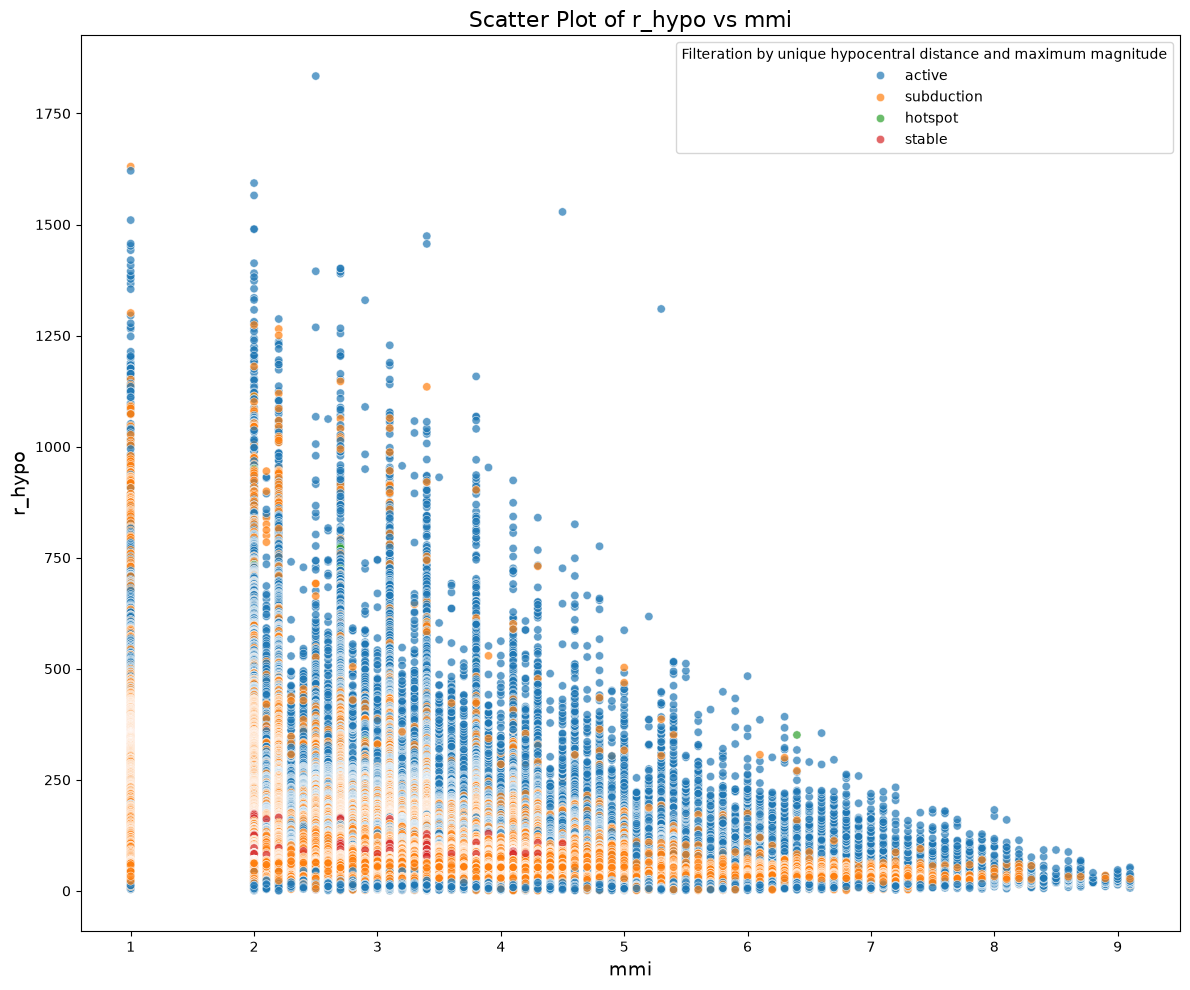

7619

In [22]:
target_feature = T1ModelSchema.RHYPO.value
used_feature = [
    T1ModelSchema.MAG.value,
    T1ModelSchema.MMI.value,
]

graph_df = filter_by_unique_extrema(df,x_col=T1ModelSchema.RHYPO.value,
         y_col=T1ModelSchema.MAG.value, operations=["max"])

for col in used_feature:
  plt.figure(figsize=(12, 10))
  sns.scatterplot(
      data=graph_df,
      x=col,
      y=target_feature,
      hue=T1ModelSchema.REGIME.value,
      alpha=0.7,
  )
  plt.title(f"Scatter Plot of {target_feature} vs {col}", fontsize=16)
  plt.xlabel(col, fontsize=14)
  plt.ylabel(target_feature, fontsize=14)  # Updated y-label to match target
  plt.legend(title="Filteration by unique hypocentral distance and maximum magnitude")
  plt.tight_layout()
  plt.show()

del graph_df, used_feature, target_feature
gc.collect()

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

class RegressorEvaluator:
	"""
	The RegressorEvaluator class provides a structured and reusable pipeline for evaluating multiple 
	regression models on a dataset. It manages the entire workflow, including data preparation, model 
	training, evaluation, and prediction generation.

	Each stage is implemented as a separate function, making it easy to customize preprocessing steps, 
	model selection, and evaluation metrics. These functions also return relevant outputs, allowing 
	intermediate results to be inspected, analyzed, or reused during the evaluation process.

	For a quick evaluation, simply call run(). It executes the complete pipeline and returns 
	both the evaluation results and prediction results as pandas DataFrames. Additional metrics 
	can be enabled or customized when needed.
	"""
	def __init__(self, df, target_col, split_id_col, models, 
				 pre_split_drop=None, post_split_drop=None, 
				 test_size=0.05, random_state=42,show_full_df=False):
		"""
		Initializes the evaluation pipeline.
		Args:
			df: The pre-transformed Pandas DataFrame.
			target_col: Name of the target variable column.
			split_id_col: Column to group by for GroupShuffleSplit (auto-dropped).
			models: Dictionary of instantiated sklearn models.
			pre_split_drop: List of columns to drop before splitting.
			post_split_drop: List of columns to drop after splitting.
			test_size: Proportion of groups to include in the test split.
			random_state: Seed for reproducibility.
		"""
		self.df = df.copy()
		self.target_col = target_col
		self.split_id_col = split_id_col
		self.models = models
		self.pre_split_drop = pre_split_drop or []
		self.post_split_drop = post_split_drop or []
		self.test_size = test_size
		self.random_state = random_state
		self.show_full_df = show_full_df

		# Placeholders for state
		self.train_df, self.test_df = None, None
		self.X_train, self.X_test = None, None
		self.y_train, self.y_test = None, None
		self.eval_df = None
		self.predictions_df = None

	def prepare_data(self):
		"""
		Handles dropping columns, GroupShuffleSplit, and X/y separation.
		Returns:
			X_train, X_test, y_train, y_test: Prepared training and testing datasets.
		"""
		# 1. Drop pre-split columns (ensuring we don't drop the split_id_col yet)
		drop_pre = [c for c in self.pre_split_drop if c in self.df.columns and c != self.split_id_col]
		if drop_pre:
			self.df = self.df.drop(columns=drop_pre)

		# 2. Group Shuffle Split
		gss = GroupShuffleSplit(n_splits=1, test_size=self.test_size, random_state=self.random_state)
		train_idx, test_idx = next(gss.split(self.df, groups=self.df[self.split_id_col]))

		self.train_df = self.df.iloc[train_idx].copy()
		self.test_df = self.df.iloc[test_idx].copy()

		# 3. Auto-drop the split_id column from train and test sets
		self.train_df = self.train_df.drop(columns=[self.split_id_col])
		self.test_df = self.test_df.drop(columns=[self.split_id_col])

		# 4. Drop post-split columns (if any)
		if self.post_split_drop:
			drop_post = [c for c in self.post_split_drop if c in self.train_df.columns]
			self.train_df = self.train_df.drop(columns=drop_post)
			self.test_df = self.test_df.drop(columns=drop_post)

		# 5. Separate Features (X) and Target (y)
		self.X_train = self.train_df.drop(columns=[self.target_col])
		self.y_train = self.train_df[self.target_col]
		self.X_test = self.test_df.drop(columns=[self.target_col])
		self.y_test = self.test_df[self.target_col]

		print(f"Train set shape: {self.X_train.shape}, {self.y_train.shape}")
		print(f"Test set shape: {self.X_test.shape}, {self.y_test.shape}")
		print(f"X_test columns: {self.X_test.columns.tolist()}")
		print(f"y_test columns: {self.y_test.name if hasattr(self.y_test, 'name') else 'N/A'}")

		return self.X_train, self.X_test, self.y_train, self.y_test

	def fit_and_evaluate(self):
		"""Trains models, prints coefficients, and calculates metrics."""
		eval_records = []

		for model_name, model in self.models.items():
			# Train the model
			model.fit(self.X_train, self.y_train)

			# Extract and print coefficients
			string = f"{model_name} Coefficients: "
			if hasattr(model, 'coef_'):
				string += str(model.coef_)
			else:
				string += "N/A"
			if hasattr(model, 'intercept_'):
				string += f", Intercept: {model.intercept_}"
			print(string)

			# Evaluate
			pred = model.predict(self.X_test)
			train_score = model.score(self.X_train, self.y_train)
			test_score = model.score(self.X_test, self.y_test)
			
			eval_records.append({
				"model": model_name,
				"train_score": train_score,
				"test_score": test_score,
				"r2_score": r2_score(self.y_test, pred),
				"mse": mean_squared_error(self.y_test, pred),
				"mae": mean_absolute_error(self.y_test, pred),
			})

		# Using list of dicts instead of pd.concat inside a loop (much faster)
		self.eval_df = pd.DataFrame(eval_records)
		return self.eval_df

	def generate_predictions(self):
		"""Appends model predictions to the test dataframe."""
		if self.test_df is None or self.X_test is None:
			raise ValueError("Data not prepared. Call prepare_data() before generating predictions.")
		if self.show_full_df:
			self.predictions_df = self.test_df.copy()
		else:
			self.predictions_df = self.test_df[[self.target_col]].copy()
		
		for model_name, model in self.models.items():
			self.predictions_df[f"{model_name}_pred"] = model.predict(self.X_test)

		return self.predictions_df

	def run(self):
		"""Executes the entire pipeline and returns evaluation and prediction DFs."""
		self.prepare_data()
		print("-" * 50)
		self.fit_and_evaluate()
		self.generate_predictions()
		
		return self.eval_df, self.predictions_df

### MODELS EXPLORATION AND EVALUATION

In [24]:
def create_unique_splits(df: pd.DataFrame, id_col: str, frac: float = 0.75, random_state: int = 42):
	unique_ids = df[id_col].unique()
	sampled_ids = pd.Series(unique_ids).sample(frac=frac, random_state=random_state)
	return df[df[id_col].isin(sampled_ids)].copy()

In [25]:
from sklearn.linear_model import (
	LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
)


def create_models() -> dict:
	"""Creates a dictionary of regression models."""
	return{
		"LinearRegression": LinearRegression(),
		"Ridge": Ridge(alpha=1.0),
		"Lasso": Lasso(alpha=0.1),
		"ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
		"BayesianRidge": BayesianRidge(),
		"HuberRegressor":HuberRegressor( max_iter=1000, alpha=0.0001)
	}


In [26]:

drop_depth_S = False  # Set to True to drop DEPTH_S before splitting
drop_r_hypo = False  # Set to True to drop RHYPO before splitting

# formula: MMI ~ a + b*Mag + c*Rhypo + log(Rhypo + 1)
# inv formula = Rhypo ~ a + b*Mag + c*MMI + log(MMI + 1)

models = create_models()

# 1. External Transformations
df_sample = df.sample(frac=0.20, random_state=42)
df_sample["log_rhypo"] = np.log10(df_sample[T1ModelSchema.RHYPO.value] + 1)

active_df = df_sample[df_sample[T1ModelSchema.REGIME.value] == "active"].copy()



# 2. Define configurations
id_col = MetadataSchema.ID.value
target = T1ModelSchema.MMI.value

# Calculate columns to drop pre-split
pre_drop = [f.value for f in MetadataSchema if f != id_col] + [T1ModelSchema.REGIME.value]

if drop_depth_S:
	pre_drop.append(T1ModelSchema.DEPTH_S.value)
if drop_r_hypo:
	pre_drop.append(T1ModelSchema.RHYPO.value)

# Define models

# 3. Instantiate and Run
evaluator = RegressorEvaluator(
	df=active_df,
	target_col=target,
	split_id_col=id_col,
	models=models,
	pre_split_drop=pre_drop,
	post_split_drop=[], 
	test_size=0.05,
	random_state=2,
	show_full_df=False
)

evaluation_metrics, test_predictions = evaluator.run()

print("\nEvaluation Metrics:\n", evaluation_metrics)
display(test_predictions)

del evaluator, active_df, df_sample, models, pre_drop, id_col, target
gc.collect()

Train set shape: (113953, 4), (113953,)
Test set shape: (5912, 4), (5912,)
X_test columns: ['magnitude', 'r_hypo', 'depth_surface', 'log_rhypo']
y_test columns: mmi
--------------------------------------------------
LinearRegression Coefficients: [ 6.26811905e-01 -3.85054479e-04  2.57574243e-02 -1.26211503e+00], Intercept: 2.079820293157841
Ridge Coefficients: [ 6.26779210e-01 -3.85866475e-04  2.57561637e-02 -1.26183433e+00], Intercept: 2.079558078947678
Lasso Coefficients: [ 0.38038119 -0.00337784  0.01686337 -0.        ], Intercept: 1.3169220580486711
ElasticNet Coefficients: [ 0.41847613 -0.00363119  0.01877194 -0.        ], Intercept: 1.1505740267446574
BayesianRidge Coefficients: [ 6.26770576e-01 -3.86080877e-04  2.57558308e-02 -1.26176021e+00], Intercept: 2.0794888433518857
HuberRegressor Coefficients: [ 5.99205092e-01 -3.42675976e-04  2.23415033e-02 -1.20765387e+00], Intercept: 2.0914437593265065

Evaluation Metrics:
               model  train_score  test_score  r2_score       

,mmi,LinearRegression_pred,Ridge_pred,Lasso_pred,ElasticNet_pred,BayesianRidge_pred,HuberRegressor_pred
161517,2.7,2.677698,2.677753,2.917250,2.922504,2.677768,2.630948
49785,3.8,3.354110,3.354075,3.146756,3.169224,3.354066,3.276421
348469,3.1,2.538443,2.538507,2.841100,2.842138,2.538524,2.480744
297931,2.2,1.056343,1.056463,1.835796,1.739007,1.056495,1.108622
605968,3.0,3.002982,3.002917,2.759640,2.740705,3.002901,2.955728
...,...,...,...,...,...,...,...
385843,3.1,2.964470,2.964506,3.077930,3.097111,2.964516,2.913728
186318,3.1,3.044703,3.044738,3.129012,3.157271,3.044747,2.991448
671242,6.6,3.447888,3.447700,2.669735,2.640053,3.447650,3.389761
108480,3.3,3.447797,3.447800,3.346513,3.391085,3.447801,3.375489


3739

In [27]:
# formula: M~ a + b*Mag + c*MMi + d*log(MMI+1) + e*log(Depth+1) + f*log(Vs30/760)
print(df.size)

df_sample = create_unique_splits(df, id_col=MetadataSchema.ID.value, frac=0.75, random_state=42)
target = T1ModelSchema.MMI.value
id_col = MetadataSchema.ID.value



active_df = df_sample[df_sample[T1ModelSchema.REGIME.value] == "active"].copy()

# Feature engineering matching the formula terms
active_df["rhypo_log"] = np.log10(active_df[T1ModelSchema.RHYPO.value] + 1)
active_df["depth_log"] = np.log10(active_df[T1ModelSchema.DEPTH_S.value] + 1)
# active_df["depth_log"] = np.log1p(active_df[T1ModelSchema.DEPTH_S.value])

pre_drop = [f.value for f in MetadataSchema if f != id_col] + [
    T1ModelSchema.REGIME.value,  # Drop regime as it's not a direct predictor
    T1ModelSchema.DEPTH_S.value,  # Drop raw 
    T1ModelSchema.RHYPO.value,  # Drop raw Rhypo in favor of log(Rhypo+1)
]

models = create_models()

evaluator = RegressorEvaluator(
    df=active_df,
    target_col=target,
    split_id_col=id_col,
    models=models,
    pre_split_drop=pre_drop,
    post_split_drop=[], 
    test_size=0.2,
    random_state=2
)

evaluation_metrics, test_predictions = evaluator.run()

print(evaluation_metrics)
display(test_predictions)

del evaluator, active_df, df_sample, models, pre_drop, id_col, target
gc.collect()


6720400
Train set shape: (355480, 3), (355480,)
Test set shape: (109420, 3), (109420,)
X_test columns: ['magnitude', 'rhypo_log', 'depth_log']
y_test columns: mmi
--------------------------------------------------
LinearRegression Coefficients: [ 0.67205797 -1.38007158  0.50089551], Intercept: 1.8204151945647828
Ridge Coefficients: [ 0.67204599 -1.38002936  0.50085398], Intercept: 1.8204362470738418
Lasso Coefficients: [ 0.2622858  -0.16513895  0.        ], Intercept: 2.003252781125763
ElasticNet Coefficients: [ 0.37944691 -0.48892884  0.        ], Intercept: 2.055740034999529
BayesianRidge Coefficients: [ 0.67204911 -1.38004036  0.50086481], Intercept: 1.820430760003716
HuberRegressor Coefficients: [ 0.6175286  -1.28419856  0.41765802], Intercept: 1.923425616218578
              model  train_score  test_score  r2_score       mse       mae
0  LinearRegression     0.323132    0.306329  0.306329  0.590092  0.595840
1             Ridge     0.323132    0.306329  0.306329  0.590092  0.59584

,mmi,LinearRegression_pred,Ridge_pred,Lasso_pred,ElasticNet_pred,BayesianRidge_pred,HuberRegressor_pred
8,8.7,5.693756,5.693693,3.698929,4.256697,5.693709,5.424273
123,4.7,4.298125,4.298091,3.066788,3.445383,4.298100,4.163058
127,4.6,4.264201,4.264169,3.062729,3.433365,4.264177,4.131492
138,5.6,4.268700,4.268667,3.063267,3.434959,4.268676,4.135678
146,7.9,5.397523,5.397466,3.526644,4.064296,5.397481,5.161889
...,...,...,...,...,...,...,...
671997,2.0,4.976176,4.976128,3.385135,3.843881,4.976140,4.773607
672017,4.9,3.491120,3.491095,2.841757,3.005481,3.491102,3.396542
672026,3.8,3.461080,3.461054,2.849178,2.987742,3.461061,3.362009
672029,3.3,2.909786,2.909771,2.630950,2.679173,2.909775,2.857560


0

In [34]:

df_sample = create_unique_splits(df, id_col=MetadataSchema.ID.value, frac=0.75, random_state=42)
active_df = df_sample[df_sample[T1ModelSchema.REGIME.value] == "active"].copy()

target = T1ModelSchema.RHYPO.value
active_df[target] = np.log10(active_df[target] + 1)

id_col = MetadataSchema.ID.value
pre_drop = [f.value for f in MetadataSchema if f != id_col] + [T1ModelSchema.REGIME.value]
active_df["log_depth"] = np.log10(active_df[T1ModelSchema.DEPTH_S.value]+1)

active_df["mag_mmi_ratio"] = active_df["magnitude"] / (active_df["mmi"] + 1.0)
active_df["mag_mmi_prod"] = active_df["magnitude"] * active_df["mmi"]

models = create_models()

evaluator = RegressorEvaluator(
    df=active_df,
    target_col=target,
    split_id_col=id_col,
    models=models,
    pre_split_drop=pre_drop,
    post_split_drop=[], 
    test_size=0.2,
    random_state=2
)

evaluation_metrics, test_predictions = evaluator.run()

print(evaluation_metrics)

tp = test_predictions.copy()

tp[target] = np.round(np.exp(tp[target]) - 1, 3)
pred_cols = [c for c in tp.columns if c.endswith("_pred")]
for col in pred_cols:
    tp[col] = np.round(np.exp(tp[col]) - 1, 3)

display(tp)

del evaluator, active_df, df_sample, models, pre_drop, id_col, target
gc.collect()

Train set shape: (355480, 6), (355480,)
Test set shape: (109420, 6), (109420,)
X_test columns: ['magnitude', 'mmi', 'depth_surface', 'log_depth', 'mag_mmi_ratio', 'mag_mmi_prod']
y_test columns: r_hypo
--------------------------------------------------
LinearRegression Coefficients: [ 0.37888314 -0.14638552  0.00234412  0.05120853 -0.10255763 -0.01123127], Intercept: 0.6975416547083155
Ridge Coefficients: [ 0.37886485 -0.14637053  0.00234542  0.05117781 -0.10250191 -0.01123074], Intercept: 0.6975239677146856
Lasso Coefficients: [ 0.19436631 -0.          0.          0.          0.         -0.00727381], Intercept: 0.9926849561595001
ElasticNet Coefficients: [ 0.27093035 -0.01134188  0.00105097  0.          0.         -0.01498439], Intercept: 0.7772723520245813
BayesianRidge Coefficients: [ 0.37883436 -0.14634556  0.00234757  0.05112669 -0.10240903 -0.01122985], Intercept: 0.6974944757658914
HuberRegressor Coefficients: [ 0.41092449 -0.13829554  0.00394305  0.04089051 -0.10739872 -0.01438

,r_hypo,LinearRegression_pred,Ridge_pred,Lasso_pred,ElasticNet_pred,BayesianRidge_pred,HuberRegressor_pred
8,1.742,3.121,3.121,5.844,4.396,3.121,2.956
123,0.814,3.118,3.118,4.486,4.032,3.118,2.978
127,0.860,3.194,3.194,4.504,4.071,3.194,3.053
138,0.854,2.490,2.490,4.330,3.692,2.490,2.355
146,1.184,2.871,2.871,5.393,4.233,2.871,2.727
...,...,...,...,...,...,...,...
671997,1.326,9.288,9.288,6.657,7.658,9.288,9.422
672017,1.867,2.462,2.462,3.980,3.460,2.462,2.334
672026,2.213,3.399,3.399,4.222,3.935,3.399,3.279
672029,2.122,2.639,2.639,3.584,3.229,2.639,2.479


1049

In [29]:
# formula: M~ a + b*Mag + c*MMi + d*log(MMI+1) + e*log(Depth+1) + f*log(Vs30/760)

df_sample = create_unique_splits(df, id_col=MetadataSchema.ID.value, frac=0.75, random_state=42)


active_df = df_sample[df_sample[T1ModelSchema.REGIME.value] == "active"].copy()

target = T1ModelSchema.RHYPO.value
active_df[target] = np.log10(active_df[target]+1)

# Feature engineering matching the formula terms
active_df["mmi_log"] = np.log10(active_df[T1ModelSchema.MMI.value] + 1)
active_df["depth_log"] = np.log10(active_df[T1ModelSchema.DEPTH_S.value] + 1)

id_col = MetadataSchema.ID.value
pre_drop = [f.value for f in MetadataSchema if f != id_col] + [
    T1ModelSchema.REGIME.value,  # Drop regime as it's not a direct predictor
    T1ModelSchema.DEPTH_S.value,  # Drop raw 
    T1ModelSchema.MMI.value,  # Drop raw MMI in favor of log(MMI+1)
]

models = create_models()

evaluator = RegressorEvaluator(
    df=active_df,
    target_col=target,
    split_id_col=id_col,
    models=models,
    pre_split_drop=pre_drop,
    post_split_drop=[], 
    test_size=0.2,
    random_state=2
)

evaluation_metrics, test_predictions = evaluator.run()

print(evaluation_metrics)

tp = test_predictions.copy()

tp[target] = np.round(np.exp(tp[target]) - 1, 3)
pred_cols = [c for c in tp.columns if c.endswith("_pred")]
for col in pred_cols:
    tp[col] = np.round(np.exp(tp[col]) - 1, 3)

display(tp)

del evaluator, active_df, df_sample, models, pre_drop, id_col, target
gc.collect()

Train set shape: (355480, 3), (355480,)
Test set shape: (109420, 3), (109420,)
X_test columns: ['magnitude', 'mmi_log', 'depth_log']
y_test columns: r_hypo
--------------------------------------------------
LinearRegression Coefficients: [ 0.307801   -1.49500093  0.08429878], Intercept: 1.1728257988044644
Ridge Coefficients: [ 0.30778752 -1.49457539  0.08427186], Intercept: 1.172668033483827
Lasso Coefficients: [0.16047944 0.         0.        ], Intercept: 1.0477221056258539
ElasticNet Coefficients: [ 0.20153086 -0.          0.        ], Intercept: 0.8671733820794367
BayesianRidge Coefficients: [ 0.30779958 -1.49495619  0.08429595], Intercept: 1.1728092123556035
HuberRegressor Coefficients: [ 0.33002439 -1.5337882   0.11086279], Intercept: 1.053227034700483
              model  train_score  test_score  r2_score       mse       mae
0  LinearRegression     0.522842    0.582822  0.582822  0.069898  0.203219
1             Ridge     0.522842    0.582827  0.582827  0.069897  0.203219
2     

,r_hypo,LinearRegression_pred,Ridge_pred,Lasso_pred,ElasticNet_pred,BayesianRidge_pred,HuberRegressor_pred
8,1.742,6.142,6.143,7.910,8.955,6.143,6.331
123,0.814,3.309,3.309,4.805,4.812,3.309,3.168
127,0.860,3.359,3.359,4.805,4.812,3.359,3.217
138,0.854,2.918,2.918,4.805,4.812,2.918,2.780
146,1.184,4.833,4.834,6.836,7.472,4.833,4.868
...,...,...,...,...,...,...,...
671997,1.326,9.134,9.133,6.232,6.660,9.134,9.269
672017,1.867,2.661,2.661,4.297,4.181,2.661,2.533
672026,2.213,3.360,3.361,4.383,4.287,3.360,3.245
672029,2.122,2.593,2.593,3.696,3.455,2.593,2.436


38

In [ ]:
# The best model based on eval is huberregressor with the following metrics:
#               model  train_score  test_score  r2_score       mse       mae
# 0  LinearRegression     0.548422    0.569148  0.569148  0.416441  0.500796
# 1             Ridge     0.548422    0.569147  0.569147  0.416441  0.500797
# 2             Lasso     0.516612    0.518908  0.518908  0.465000  0.544122
# 3        ElasticNet     0.530496    0.536431  0.536431  0.448064  0.531592
# 4     BayesianRidge     0.548422    0.569146  0.569146  0.416442  0.500798
# 5    HuberRegressor     0.544265    0.572939  0.572939  0.412776  0.492307


### HuberRegressor Model Hyperparameter Tuning

In [35]:
from sklearn.model_selection import GroupShuffleSplit


def prepare_data(
    df,
    target_col: str,
    split_id_col: str,
    train_splitter=None,
    val_test_splitter=None,
    pre_split_drop: list[str] | None = None,
    post_split_drop: list[str] | None = None,
):
    """
    Prepare train/validation/test datasets using grouped splitting.

    Args:
        df: Input dataframe.
        target_col: Target column name.
        split_id_col: Group column used for splitting.
        train_splitter: Splitter for Train vs (Val+Test).
        val_test_splitter: Splitter for Val vs Test.
        pre_split_drop: Columns to drop before splitting.
        post_split_drop: Columns to drop after splitting.

    Returns:
        (
            X_train, X_val, X_test,
            y_train, y_val, y_test
        )
    """
    df = df.copy()

    pre_split_drop = pre_split_drop or []
    post_split_drop = post_split_drop or []

    # Default splitters
    if train_splitter is None:
        train_splitter = GroupShuffleSplit(
            n_splits=1,
            test_size=0.30,  # 70% train, 30% temp
            random_state=42,
        )

    if val_test_splitter is None:
        val_test_splitter = GroupShuffleSplit(
            n_splits=1,
            test_size=0.50,  # split temp into 50/50
            random_state=42,
        )

    # Drop pre-split columns
    drop_pre = [
        c for c in pre_split_drop
        if c in df.columns and c != split_id_col
    ]

    if drop_pre:
        df = df.drop(columns=drop_pre)

    # --------------------------------------------------
    # Stage 1: Train vs Temp
    # --------------------------------------------------

    train_idx, temp_idx = next(
        train_splitter.split(
            df,
            groups=df[split_id_col],
        )
    )

    train_df = df.iloc[train_idx].copy()
    temp_df = df.iloc[temp_idx].copy()

    # --------------------------------------------------
    # Stage 2: Validation vs Test
    # --------------------------------------------------

    val_idx, test_idx = next(
        val_test_splitter.split(
            temp_df,
            groups=temp_df[split_id_col],
        )
    )

    val_df = temp_df.iloc[val_idx].copy()
    test_df = temp_df.iloc[test_idx].copy()

    # Remove group column
    train_df = train_df.drop(columns=[split_id_col])
    val_df = val_df.drop(columns=[split_id_col])
    test_df = test_df.drop(columns=[split_id_col])

    # Drop post-split columns
    if post_split_drop:
        drop_post = [
            c for c in post_split_drop
            if c in train_df.columns
        ]

        if drop_post:
            train_df = train_df.drop(columns=drop_post)
            val_df = val_df.drop(columns=drop_post)
            test_df = test_df.drop(columns=drop_post)

    # X/y split
    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]

    X_val = val_df.drop(columns=[target_col])
    y_val = val_df[target_col]

    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col]

    return (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test,
    )

In [36]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
	n_splits=1,
	test_size=0.2,
	random_state=42,
)
df_sample = df.sample(frac =1.0, random_state=42)
df_sample = df_sample[df_sample[T1ModelSchema.REGIME.value] == "active"].copy()
id_col = MetadataSchema.ID.value

(X_train, X_val, X_test, y_train, y_val, y_test) = prepare_data(
	df=df_sample,
	target_col=T1ModelSchema.RHYPO.value,
	split_id_col=MetadataSchema.ID.value,
	train_splitter=splitter,
	val_test_splitter=splitter,
	pre_split_drop=[f.value for f in MetadataSchema if f != id_col] + [T1ModelSchema.REGIME.value]
)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

del df_sample, splitter
gc.collect()

X_train shape: (479721, 3), y_train shape: (479721,)
X_val shape: (87927, 3), y_val shape: (87927,)
X_test shape: (32244, 3), y_test shape: (32244,)


2324

### Randomized Search CV for Hyperparameter Tuning

In [ ]:
# from sklearn.linear_model import HuberRegressor
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from scipy.stats import loguniform, uniform
# from sklearn.model_selection import RandomizedSearchCV

# model = HuberRegressor(max_iter=1000)

# print("--- Starting Stage 1: RandomizedSearchCV ---")

# random_param_distributions = {
#     # Sample epsilon continuously between 1.1 and 2.0
#     "epsilon": uniform(1.1, 0.9),
#     # Sample alpha across 7 orders of magnitude on a log scale
#     "alpha": loguniform(1e-6, 10.0),
#     "tol": [1e-4, 1e-5, 1e-6],
# }
# ns = [5, 10, 20,]

# for n_iter in ns:
# 	print(f"\nRunning RandomizedSearchCV with n_iter={n_iter}...")
# 	random_search = RandomizedSearchCV(
#     estimator=model,
#     param_distributions=random_param_distributions,
#     n_iter=n_iter,
#     cv=5,
#     scoring="r2",
#     n_jobs=-1,
#     random_state=42,
#     verbose=1,
# 	)

# 	random_search.fit(X_train, y_train)
# 	best_eps = random_search.best_params_["epsilon"]
# 	best_alpha = random_search.best_params_["alpha"]
# 	best_tol = random_search.best_params_["tol"]

# 	print(
# 		f"Best Params total for n_iter={n_iter}: Epsilon={best_eps:.4f}, Alpha={best_alpha:.6f}, Tol={best_tol}"
# 	)
# 	best_model = random_search.best_estimator_
# 	y_pred = best_model.predict(X_test)

# 	print("\n--- Corrected Results ---")
# 	print("Best Parameters Found:", random_search.best_params_)
# 	print(f"Test Set R² Score   : {r2_score(y_test, y_pred):.6f}")
# 	print(f"Test Set MSE        : {mean_squared_error(y_test, y_pred):.6f}")
# 	print(f"Test Set MAE        : {mean_absolute_error(y_test, y_pred):.6f}")

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# print("--- Restored Stage 2: Robust Huber Tuning ---")

# robust_param_grid = {
#     "epsilon": [1.1, 1.25, 1.35, 1.5, 1.65, 1.75],
#     "alpha": [1e-4, 1e-3, 1e-2, 0.1, 1.0],
#     "tol": [1e-5]
# }

# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=robust_param_grid,
#     cv=5,
#     scoring="neg_mean_absolute_error", 
#     n_jobs=-1,
#     verbose=1
# )

# grid_search.fit(X_train, y_train)


# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test)

# print("\n--- Corrected Results ---")
# print("Best Parameters Found:", grid_search.best_params_)
# print(f"Test Set R² Score   : {r2_score(y_test, y_pred):.6f}")
# print(f"Test Set MSE        : {mean_squared_error(y_test, y_pred):.6f}")
# print(f"Test Set MAE        : {mean_absolute_error(y_test, y_pred):.6f}")